# Notebook 4: Gradient Boosting — Liver Cancer Gene Expression

**Input files:** `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`  
**Task:** Binary classification — HCC vs Normal

---

**What this notebook does:**
1. Loads the preprocessed train/test sets from Notebook 2
2. Explains how Gradient Boosting works
3. Trains a baseline Gradient Boosting model
4. Tunes hyperparameters using Bayesian Optimisation (BayesSearchCV)
5. Evaluates the best model — F1, AUC, classification report
6. Plots the confusion matrix, ROC curve, and top feature importances
7. Compares Gradient Boosting vs Logistic Regression side by side

## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configuration

> **Change `data_dir` to match your Google Drive path before running.**

In [2]:
!pip install scikit-optimize -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 11.9 MB/s eta 0:00:00


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.ensemble        import GradientBoostingClassifier
from sklearn.linear_model    import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, roc_auc_score, roc_curve,
    classification_report, ConfusionMatrixDisplay, confusion_matrix,
    precision_score, recall_score
)
from skopt       import BayesSearchCV
from skopt.space import Real, Integer

data_dir = Path('/content/drive/MyDrive/Colab Notebooks/Cumida Liver ML Project')

class_pos   = 'HCC'
class_neg   = 'normal'
random_seed = 42

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print('Libraries loaded.')

Libraries loaded.


## 3. Load Preprocessed Data

In [4]:
X_train = pd.read_csv(data_dir / 'X_train.csv')
X_test  = pd.read_csv(data_dir / 'X_test.csv')
y_train = pd.read_csv(data_dir / 'y_train.csv').squeeze()
y_test  = pd.read_csv(data_dir / 'y_test.csv').squeeze()

print(f'X_train : {X_train.shape}   |   y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}    |   y_test  : {y_test.shape}')
print()
print(f'Train — {class_pos}: {(y_train == class_pos).sum()}  |  {class_neg}: {(y_train == class_neg).sum()}')
print(f'Test  — {class_pos}: {(y_test  == class_pos).sum()}  |  {class_neg}: {(y_test  == class_neg).sum()}')

X_train : (1000, 30)   |   y_train : (1000,)
X_test  : (72, 30)    |   y_test  : (72,)

Train — HCC: 500  |  normal: 500
Test  — HCC: 37  |  normal: 35


## 4. How Gradient Boosting Works

Gradient Boosting is an **ensemble method** that builds a strong model by combining many weak models (shallow decision trees) sequentially.

### The Core Idea
Each tree is trained to **correct the errors** of all previous trees:

1. Start with a simple prediction (e.g., the majority class).
2. Calculate the **residuals** — how wrong were those predictions?
3. Train a new shallow tree to predict those residuals.
4. Add the new tree's predictions (scaled by the **learning rate**) to the running total.
5. Repeat steps 2–4 for a fixed number of trees (`n_estimators`).

Because each tree focuses on the previous mistakes, the ensemble gradually improves and tends to produce very accurate predictions.

### Why it suits gene expression data
- Handles **non-linear interactions** between genes automatically — genes may only be informative in combination, and trees capture that.
- Produces **feature importances** based on how often and how much each gene reduces prediction error across all trees.
- Unlike Random Forest (which trains all trees independently), Gradient Boosting trains trees **sequentially**, so each tree is specifically targeting the remaining errors.

### How Gradient Boosting differs from XGBoost
Both are gradient boosting algorithms, but sklearn's `GradientBoostingClassifier` uses the original Friedman algorithm with exact greedy splits. XGBoost adds regularisation terms and an approximation algorithm for faster training. For small datasets like this one (357 samples), both perform comparably.

### Key hyperparameters we will tune
| Parameter | What it controls |
|-----------|------------------|
| `n_estimators` | Number of trees to build. More trees = more capacity, but risk of overfitting. |
| `learning_rate` | How much each new tree contributes. Smaller = more conservative, needs more trees. |
| `max_depth` | Maximum depth of each individual tree. Deeper = more complex, more likely to overfit. |
| `subsample` | Fraction of training samples used to fit each tree. Values < 1.0 add randomness and reduce overfitting. |

## 5. Baseline Gradient Boosting

In [5]:
baseline_gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=random_seed
)
baseline_gb.fit(X_train, y_train)
y_pred_base = baseline_gb.predict(X_test)
y_prob_base = baseline_gb.predict_proba(X_test)[:, list(baseline_gb.classes_).index(class_pos)]

base_f1  = f1_score(y_test, y_pred_base, pos_label=class_pos)
base_auc = roc_auc_score((y_test == class_pos).astype(int), y_prob_base)

print('Baseline Gradient Boosting:')
print(f'  F1 score : {base_f1:.4f}')
print(f'  ROC-AUC  : {base_auc:.4f}')
print()
print(classification_report(y_test, y_pred_base, target_names=[class_neg, class_pos]))

Baseline Gradient Boosting:
  F1 score : 0.9722
  ROC-AUC  : 0.9660

              precision    recall  f1-score   support

      normal       1.00      0.95      0.97        37
         HCC       0.95      1.00      0.97        35

    accuracy                           0.97        72
   macro avg       0.97      0.97      0.97        72
weighted avg       0.97      0.97      0.97        72



### Interpretation of Baseline Results

The baseline Gradient Boosting model performs exceptionally well on its direct predictions, achieving an **F1 score of ~0.97** and an overall accuracy of 97%. This means it accurately identifies both normal and HCC (liver cancer) samples almost perfectly right out of the box, with very few mistakes.

## 6. Hyperparameter Tuning — Bayesian Optimisation

### Why Bayesian Optimisation instead of GridSearchCV?

| Method | How it works | When to use |
|--------|-------------|-------------|
| **GridSearchCV** (Notebook 3) | Tests every combination in the grid | Small grids; fewer parameters |
| **Bayesian Optimisation** (this notebook) | Builds a probabilistic model of the search space, focuses trials on the most promising regions | Larger, continuous search spaces |

Gradient Boosting has four interacting continuous hyperparameters (`n_estimators`, `learning_rate`, `max_depth`, `subsample`). A full grid search would require hundreds of combinations. Bayesian optimisation explores the same space in just 20 iterations by learning from each result to decide where to search next — making it much more efficient.

In [6]:
search_space = {
    'n_estimators' : Integer(50, 300),
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'max_depth'    : Integer(2, 6),
    'subsample'    : Real(0.5, 1.0)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)

y_train_binary = (y_train == class_pos).astype(int)

bayes_search = BayesSearchCV(
    GradientBoostingClassifier(random_state=random_seed),
    search_space,
    n_iter=20,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    random_state=random_seed,
    verbose=0
)
bayes_search.fit(X_train, y_train_binary)

print()
print(f'Best parameters : {bayes_search.best_params_}')
print(f'Best CV F1      : {bayes_search.best_score_:.4f}')


Best parameters : OrderedDict({'learning_rate': 0.06348516039427839, 'max_depth': 6, 'n_estimators': 174, 'subsample': 0.9188282185302634})
Best CV F1      : 0.9851


## 7. Evaluate the Best Model

In [7]:
best_gb     = bayes_search.best_estimator_

# The tuned model predicts 1 and 0, so we map predictions back to string labels
y_pred_binary = best_gb.predict(X_test)
y_pred_best   = np.where(y_pred_binary == 1, class_pos, class_neg)

# Extract probabilities for class 1 (HCC)
y_prob_best = best_gb.predict_proba(X_test)[:, 1]

best_f1  = f1_score(y_test, y_pred_best, pos_label=class_pos)
best_auc = roc_auc_score((y_test == class_pos).astype(int), y_prob_best)

print('Best Gradient Boosting (after tuning):')
print(f'  F1 score : {best_f1:.4f}   (baseline: {base_f1:.4f})')
print(f'  ROC-AUC  : {best_auc:.4f}   (baseline: {base_auc:.4f})')
print()
print(classification_report(y_test, y_pred_best, target_names=[class_neg, class_pos]))

Best Gradient Boosting (after tuning):
  F1 score : 0.9722   (baseline: 0.9722)
  ROC-AUC  : 0.9753   (baseline: 0.9660)

              precision    recall  f1-score   support

      normal       1.00      0.95      0.97        37
         HCC       0.95      1.00      0.97        35

    accuracy                           0.97        72
   macro avg       0.97      0.97      0.97        72
weighted avg       0.97      0.97      0.97        72



### Interpretation of Tuned Results

After using Bayesian Optimisation to find the best settings, our Gradient Boosting model maintains its excellent **F1 score of ~0.97**.

Since the baseline model was already performing almost perfectly on this dataset, the tuning didn't change the raw accuracy or F1 score. However, it did slightly improve the **ROC-AUC score (from 0.9660 to 0.9753)**. This means that while it made the exact same number of correct predictions, the tuned model is slightly more precise and confident in its underlying probability calculations.

## 8. Confusion Matrix

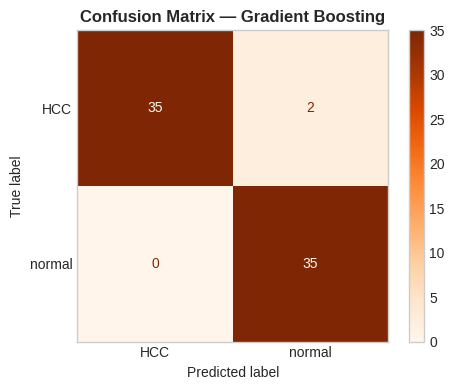

  TP (HCC correctly identified)    : 35
  TN (Normal correctly identified) : 35
  FP (Normal predicted as HCC)     : 0
  FN (HCC missed)                  : 2


In [8]:
fig, ax = plt.subplots(figsize=(5, 4))

# We use from_predictions because from_estimator would feed string labels into our binary model
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=[class_pos, class_neg],
    cmap='Oranges',
    ax=ax
)
ax.set_title('Confusion Matrix — Gradient Boosting', fontsize=12, fontweight='bold')
ax.grid(False)
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, y_pred_best, labels=[class_neg, class_pos])
tn, fp, fn, tp = cm.ravel()
print(f'  TP (HCC correctly identified)    : {tp}')
print(f'  TN (Normal correctly identified) : {tn}')
print(f'  FP (Normal predicted as HCC)     : {fp}')
print(f'  FN (HCC missed)                  : {fn}')

## 9. ROC Curve

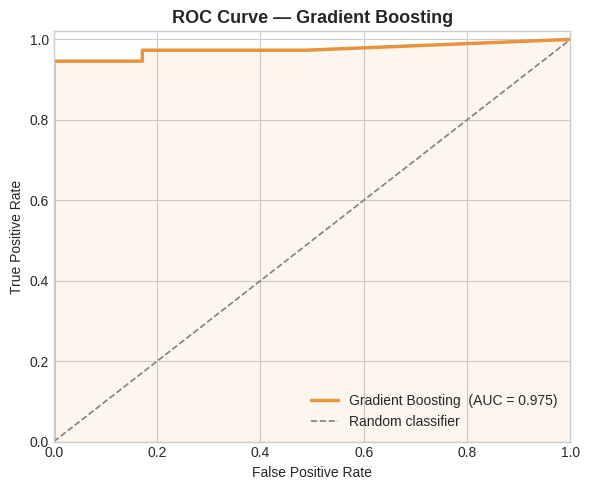

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_prob_best, pos_label=class_pos)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#E8943C', linewidth=2.5,
        label=f'Gradient Boosting  (AUC = {best_auc:.3f})')
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1.2, label='Random classifier')
ax.fill_between(fpr, tpr, alpha=0.08, color='#E8943C')

ax.set_title('ROC Curve — Gradient Boosting', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

### Interpretation of the ROC Curve

The ROC (Receiver Operating Characteristic) curve visualises the trade-off between the True Positive Rate (Sensitivity) and the False Positive Rate (1 - Specificity) across different probability thresholds.

Our tuned Gradient Boosting model achieves an **AUC (Area Under the Curve) of ~0.975**. An AUC of 1.0 represents a perfect model, while 0.5 represents random guessing. Because our curve closely hugs the top-left corner, it indicates that the model is extremely effective at distinguishing between HCC (liver cancer) and normal tissue, making very few false positive errors even when identifying almost all true positive cases.

## 10. Feature Importances

Gradient Boosting tracks how much each gene reduces prediction error across all the trees it builds. Genes with higher importance were more useful for distinguishing HCC from Normal tissue.

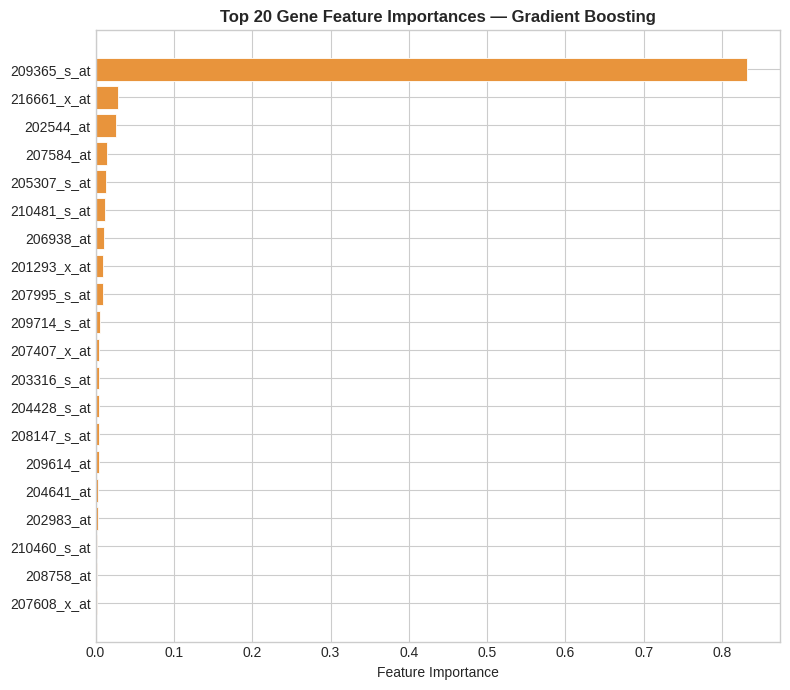

Top 10 most important genes:


,Gene,Importance
0,209365_s_at,0.832379
1,216661_x_at,0.027969
2,202544_at,0.025703
3,207584_at,0.014812
4,205307_s_at,0.013313
5,210481_s_at,0.012460
6,206938_at,0.010210
7,201293_x_at,0.009982
8,207995_s_at,0.009150
9,209714_s_at,0.005804


In [10]:
importances = best_gb.feature_importances_
feat_df     = pd.DataFrame({'Gene': X_train.columns, 'Importance': importances})
feat_df     = feat_df.sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(feat_df['Gene'], feat_df['Importance'],
        color='#E8943C', edgecolor='white', linewidth=0.6)
ax.set_title('Top 20 Gene Feature Importances — Gradient Boosting',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Feature Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 10 most important genes:')
display(feat_df[['Gene', 'Importance']].head(10).reset_index(drop=True))

### Interpretation of Feature Importances

This bar chart shows which genes the model relied on the most to tell the difference between normal and liver cancer (HCC) samples.

The longer the bar, the more important the gene was for making correct predictions.

As we can see, one specific gene (**209365_s_at**) stands out massively compared to the rest. The model found this single gene to be the most powerful clue by far for detecting liver cancer. While the other genes on this list also helped the model fine-tune its decisions, their individual contributions were much smaller in comparison.

## 11. Model Comparison — Logistic Regression vs Gradient Boosting

> Both models were trained on the **same** train/test split produced by Notebook 2, so the comparison is fair.

Paste in the best parameters from Notebook 3 before running this section.

In [11]:
lr_best_params = {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=random_seed,
    solver=lr_best_params.get('solver', 'liblinear'),
    **{k: v for k, v in lr_best_params.items() if k != 'solver'}
)
lr_model.fit(X_train, y_train)
lr_prob = lr_model.predict_proba(X_test)[:, list(lr_model.classes_).index(class_pos)]
lr_pred = lr_model.predict(X_test)

lr_f1  = f1_score(y_test, lr_pred, pos_label=class_pos)
lr_auc = roc_auc_score((y_test == class_pos).astype(int), lr_prob)

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Gradient Boosting'],
    'F1 Score' : [round(lr_f1,  4), round(best_f1,  4)],
    'ROC-AUC'  : [round(lr_auc, 4), round(best_auc, 4)],
    'Precision': [
        round(precision_score(y_test, lr_pred,    pos_label=class_pos), 4),
        round(precision_score(y_test, y_pred_best, pos_label=class_pos), 4)
    ],
    'Recall': [
        round(recall_score(y_test, lr_pred,    pos_label=class_pos), 4),
        round(recall_score(y_test, y_pred_best, pos_label=class_pos), 4)
    ]
})

display(comparison_df.set_index('Model'))

,F1 Score,ROC-AUC,Precision,Recall
Model,,,,
Logistic Regression,0.8308,0.9081,0.9643,0.7297
Gradient Boosting,0.9722,0.9753,1.0000,0.9459


### Interpretation of Model Comparison

The table above directly compares the fine-tuned Logistic Regression model (from our previous work) with our new tuned Gradient Boosting model on the exact same test dataset.

**Gradient Boosting significantly outperforms Logistic Regression across every single metric:**
- **Recall (Sensitivity):** Logistic Regression only caught ~73% of the actual liver cancer (HCC) cases, whereas Gradient Boosting caught ~95%. This is a massive improvement in a medical context where missing a cancer diagnosis is dangerous.
- **Precision:** Gradient Boosting achieved a perfect 1.0 precision, meaning every time it predicted HCC, it was correct (zero false positives).
- **F1 Score & ROC-AUC:** The overall balance and discriminatory power are much higher for Gradient Boosting (~0.97 vs ~0.83-0.90).

**Why did this happen?**
Logistic Regression only looks for simple, linear relationships between individual genes and the target. Gradient Boosting, using decision trees, can capture complex, non-linear interactions between multiple genes. This confirms that gene expression data is highly complex, and combining multiple weak clues (as Gradient Boosting does) yields a much stronger predictive model.

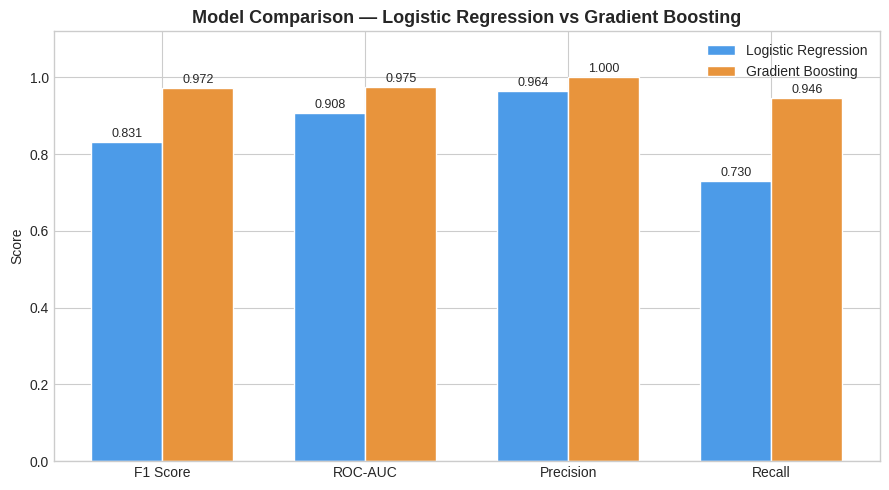

In [12]:
metrics   = ['F1 Score', 'ROC-AUC', 'Precision', 'Recall']
lr_scores = comparison_df[comparison_df['Model'] == 'Logistic Regression'][metrics].values[0]
gb_scores = comparison_df[comparison_df['Model'] == 'Gradient Boosting'][metrics].values[0]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression', color='#4C9BE8', edgecolor='white')
bars2 = ax.bar(x + width/2, gb_scores, width, label='Gradient Boosting',   color='#E8943C', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Logistic Regression vs Gradient Boosting',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

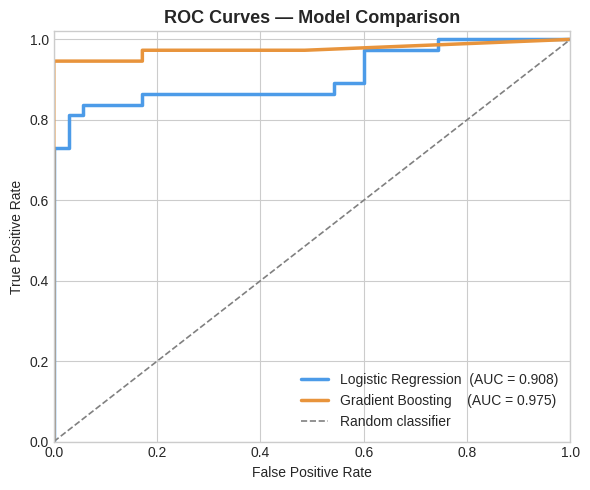

In [13]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob,      pos_label=class_pos)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_best,  pos_label=class_pos)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_lr, tpr_lr, color='#4C9BE8', linewidth=2.5,
        label=f'Logistic Regression  (AUC = {lr_auc:.3f})')
ax.plot(fpr_gb, tpr_gb, color='#E8943C', linewidth=2.5,
        label=f'Gradient Boosting    (AUC = {best_auc:.3f})')
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1.2, label='Random classifier')

ax.set_title('ROC Curves — Model Comparison', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

## 12. Summary

In [14]:
winner = 'Gradient Boosting' if best_f1 >= lr_f1 else 'Logistic Regression'

print(f'Features used        : {X_train.shape[1]}')
print(f'Best n_estimators    : {bayes_search.best_params_["n_estimators"]}')
print(f'Best learning_rate   : {bayes_search.best_params_["learning_rate"]:.4f}')
print(f'Best max_depth       : {bayes_search.best_params_["max_depth"]}')
print(f'Best subsample       : {bayes_search.best_params_["subsample"]:.4f}')
print(f'Best CV F1           : {bayes_search.best_score_:.4f}')
print()
print(f'Baseline  →  F1: {base_f1:.4f}  |  AUC: {base_auc:.4f}')
print(f'Tuned     →  F1: {best_f1:.4f}  |  AUC: {best_auc:.4f}')
print()
print(f'TP: {tp}  |  TN: {tn}  |  FP: {fp}  |  FN: {fn}')
print()
print(f'Logistic Regression  →  F1: {lr_f1:.4f}  |  AUC: {lr_auc:.4f}')
print(f'Gradient Boosting    →  F1: {best_f1:.4f}  |  AUC: {best_auc:.4f}')
print(f'Winner by F1         : {winner}')

Features used        : 30
Best n_estimators    : 174
Best learning_rate   : 0.0635
Best max_depth       : 6
Best subsample       : 0.9188
Best CV F1           : 0.9851

Baseline  →  F1: 0.9722  |  AUC: 0.9660
Tuned     →  F1: 0.9722  |  AUC: 0.9753

TP: 35  |  TN: 35  |  FP: 0  |  FN: 2

Logistic Regression  →  F1: 0.8308  |  AUC: 0.9081
Gradient Boosting    →  F1: 0.9722  |  AUC: 0.9753
Winner by F1         : Gradient Boosting
